## 1. Import Required Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

## 2. Load the Dataset

In [16]:
# Load the dataset
df = pd.read_csv('WB_WDI_WIDEF.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (289303, 105)

First few rows:
       STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      EAS   
1  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      AFW   
2  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      UZB   
3  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VUT   
4  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ECA   

                  INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0  WB_WDI_NY_ADJ_DFOR_GN_ZS  _T  _T           _T       PT_GNI  ...   
1  WB_WDI_SE_PRM_CMPT_MA_ZS   M  _T           _T           PT  ...   
2     WB_WDI_IT_NET_USER_ZS  _T  _T           _T       PT_POP  ...   
3     WB_WDI_SH_H2O_BASW_ZS  _T  _T           _T       PT_POP  ...   
4        WB_WDI_IT_NET_BBND  _T  _T           _T           SB  ...   

           2016          2017          2018          2019          2020  \
0  3.626843e-02  4.313230e-02  3.646513e-02

## 3. Inspect the INDICATORS Column

In [17]:
# Display information about the INDICATOR column
print("INDICATOR Column Data Type:", df['INDICATOR_LABEL'].dtype)
print("\nFirst 10 values of INDICATOR column:")
print(df['INDICATOR_LABEL'].head(10))
print("\nBasic Statistics:")
print(f"Total rows: {len(df)}")
print(f"Data type: {df['INDICATOR_LABEL'].dtype}")

INDICATOR Column Data Type: str

First 10 values of INDICATOR column:
0    Adjusted savings: net forest depletion (% of GNI)
1    Primary completion rate, male (% of relevant a...
2     Individuals using the Internet (% of population)
3    People using at least basic drinking water ser...
4                        Fixed broadband subscriptions
5    Adjusted net savings, excluding particulate em...
6       Mobile cellular subscriptions (per 100 people)
7             Survival to age 65, female (% of cohort)
8    Households and NPISHs Final consumption expend...
9    Prevalence of anemia among children (% of chil...
Name: INDICATOR_LABEL, dtype: str

Basic Statistics:
Total rows: 289303
Data type: str


## 4. Check for Missing Values in INDICATORS

Missing Values Analysis for INDICATOR Column:
Total missing values: 0
Percentage of missing values: 0.00%
Non-missing values: 289303


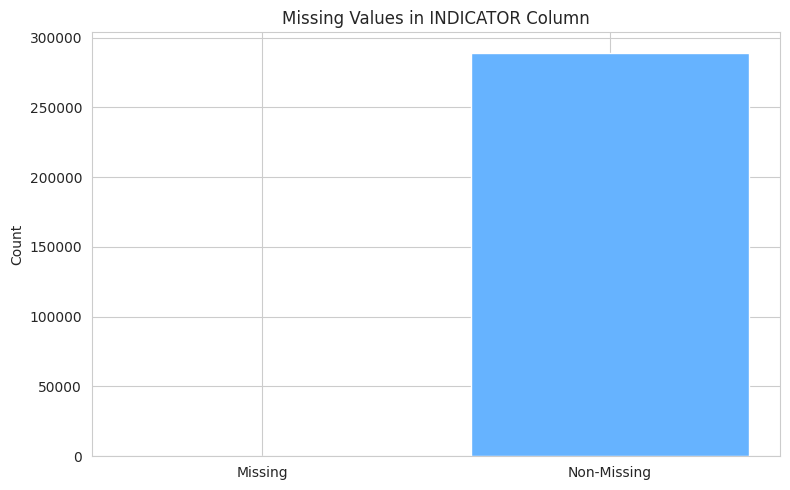

In [18]:
# Check for missing values
missing_count = df['INDICATOR_LABEL'].isna().sum()
missing_percentage = (missing_count / len(df)) * 100

print("Missing Values Analysis for INDICATOR Column:")
print(f"Total missing values: {missing_count}")
print(f"Percentage of missing values: {missing_percentage:.2f}%")
print(f"Non-missing values: {len(df) - missing_count}")

# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 5))
missing_data = [missing_count, len(df) - missing_count]
labels = ['Missing', 'Non-Missing']
colors = ['#ff9999', '#66b3ff']
ax.bar(labels, missing_data, color=colors)
ax.set_ylabel('Count')
ax.set_title('Missing Values in INDICATOR Column')
plt.tight_layout()
plt.show()

## 5. Analyze Unique Values in INDICATORS

In [19]:
# Analyze unique values
unique_count = df['INDICATOR_LABEL'].nunique()
print(f"Number of unique INDICATOR values: {unique_count}")
print(f"\nUnique values representation: {(unique_count / len(df)) * 100:.2f}% of total rows")

# Display frequency of each indicator
indicator_counts = df['INDICATOR_LABEL'].value_counts()
print(f"\nTop 15 Most Frequent INDICATOR Values:")
print(indicator_counts.head(15))

print(f"\n Bottom 10 Least Frequent INDICATOR Values:")
print(indicator_counts.tail(10))

# Summary statistics
print(f"\nFrequency Statistics:")
print(f"Mean frequency: {indicator_counts.mean():.2f}")
print(f"Median frequency: {indicator_counts.median():.2f}")
print(f"Max frequency: {indicator_counts.max()}")
print(f"Min frequency: {indicator_counts.min()}")

Number of unique INDICATOR values: 1486

Unique values representation: 0.51% of total rows

Top 15 Most Frequent INDICATOR Values:
INDICATOR_LABEL
Survival to age 65, female (% of cohort)                         265
Population ages 65 and above, male                               265
Population ages 15-64, total                                     265
Rural population                                                 265
Rural population (% of total population)                         265
Life expectancy at birth, male (years)                           265
Population ages 15-64 (% of total population)                    265
Population ages 30-34, female (% of female population)           265
Population ages 05-09, female (% of female population)           265
Population ages 50-54, male (% of male population)               265
Population ages 55-59, female (% of female population)           265
Life expectancy at birth, female (years)                         265
Population ages 65 and ab

## 6. Visualize Distribution of INDICATORS

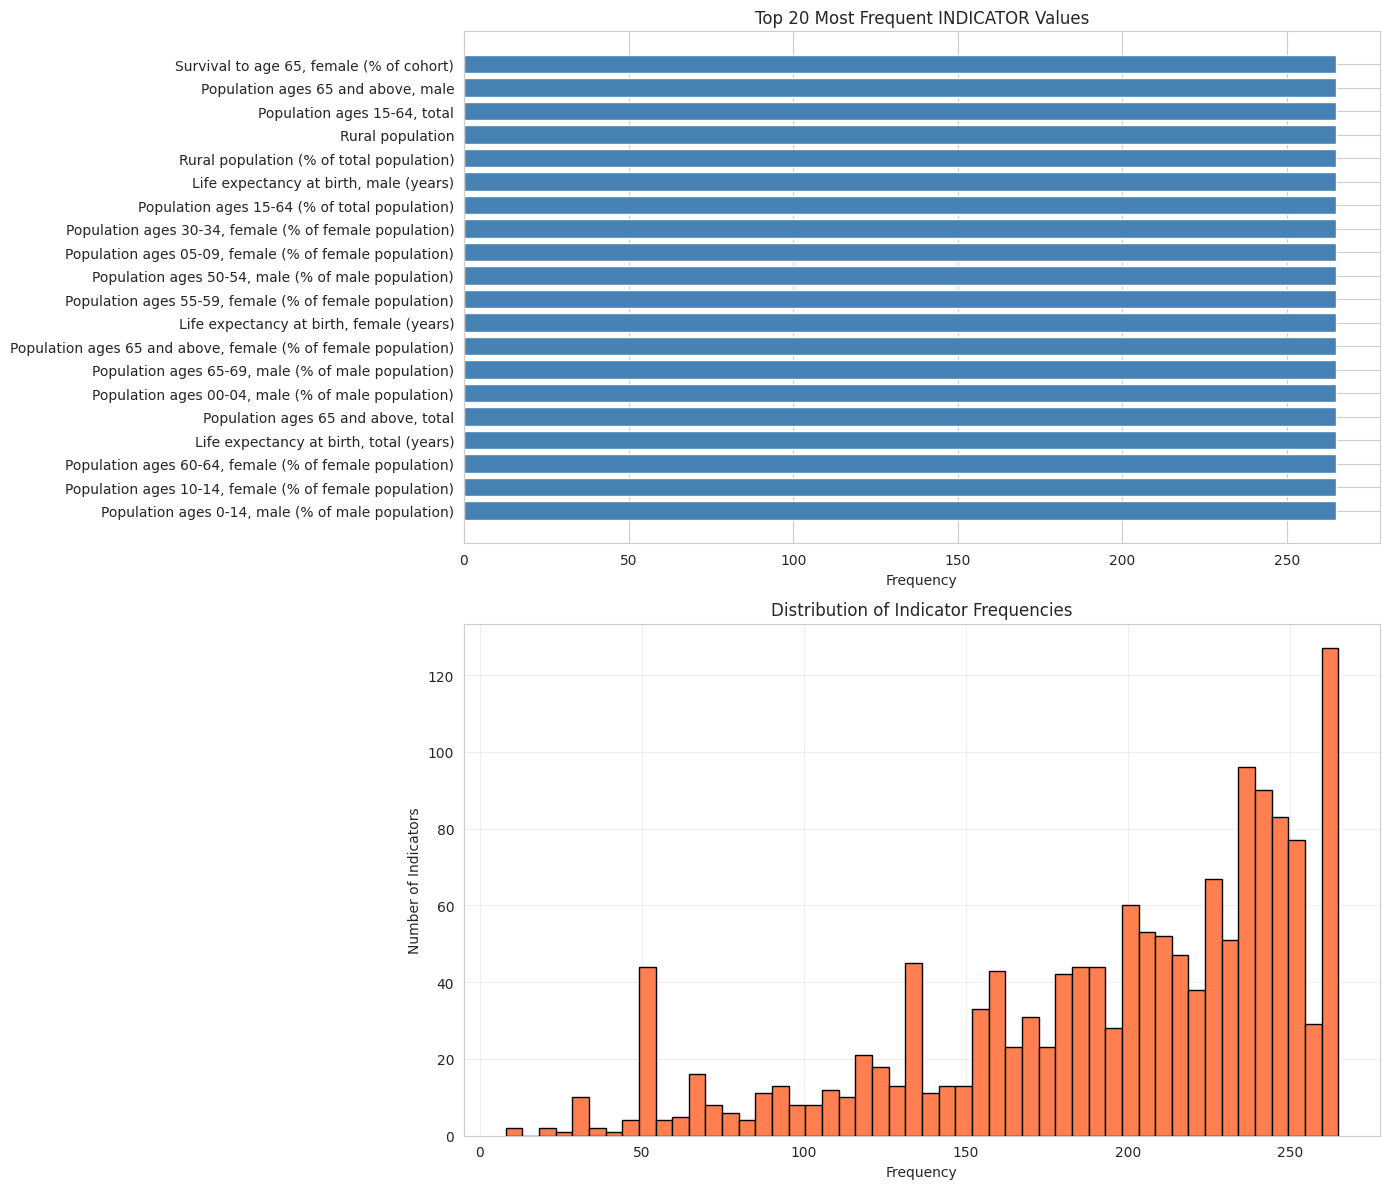

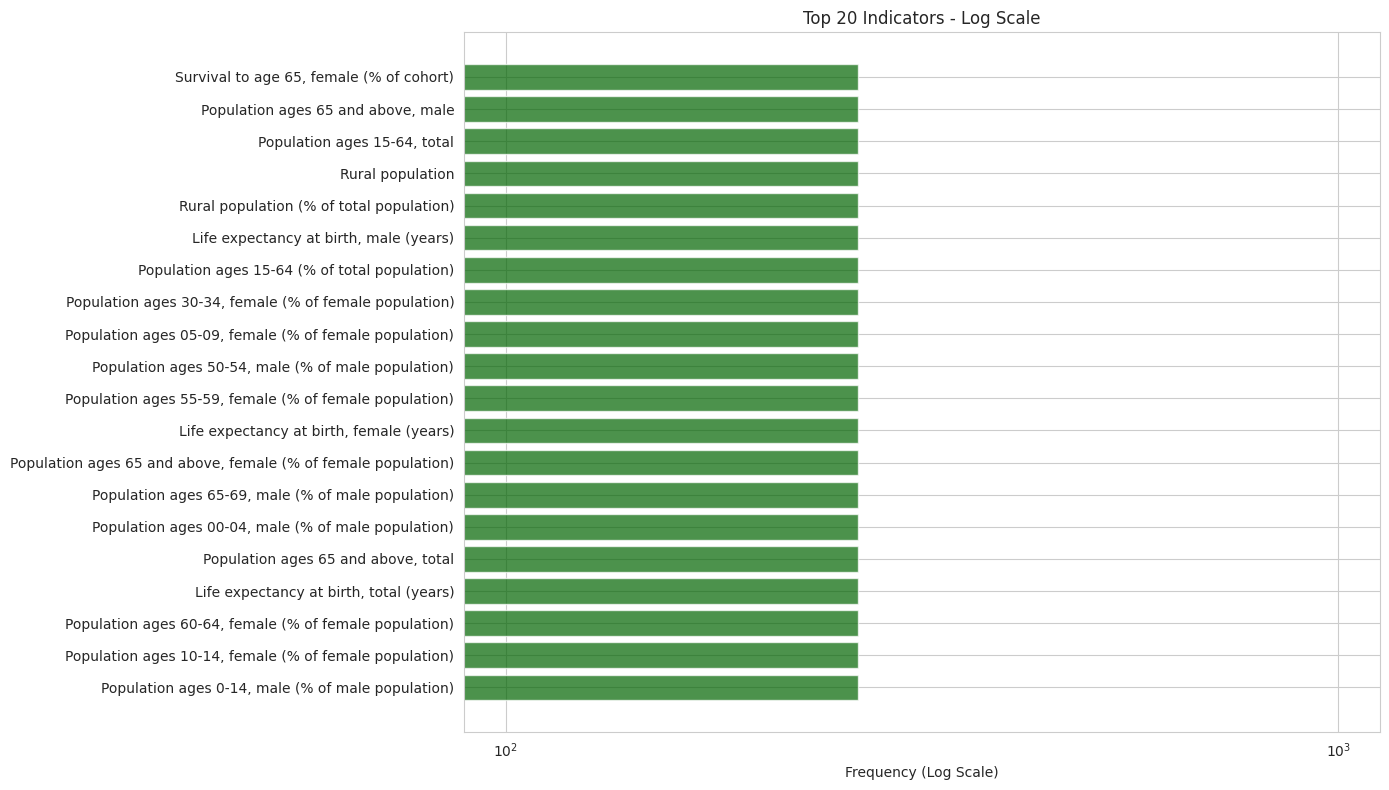

In [20]:
# Visualize top 20 indicators
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 20 indicators
top_20 = indicator_counts.head(20)
axes[0].barh(range(len(top_20)), top_20.values, color='steelblue')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20.index)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Most Frequent INDICATOR Values')
axes[0].invert_yaxis()

# Distribution of frequencies (histogram)
axes[1].hist(indicator_counts.values, bins=50, color='coral', edgecolor='black')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Number of Indicators')
axes[1].set_title('Distribution of Indicator Frequencies')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Log scale visualization for better understanding
fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(len(top_20)), top_20.values, color='darkgreen', alpha=0.7)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.set_xlabel('Frequency (Log Scale)')
ax.set_xscale('log')
ax.set_title('Top 20 Indicators - Log Scale')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Cross-tabulate INDICATORS with Other Columns

CROSS-TABULATION ANALYSIS

Available columns in the dataset:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '



Cross-tabulation: INDICATOR vs REF_AREA (Top 10 indicators)
REF_AREA                                            ABW  AFE  AFG  AFW  AGO  \
INDICATOR_LABEL                                                               
ARI treatment (% of children under 5 taken to a...    0    0    1    1    1   
Access to clean fuels and technologies for cook...    0    1    1    1    1   
Access to clean fuels and technologies for cook...    0    1    1    1    1   
Access to clean fuels and technologies for cook...    0    1    1    1    1   
Access to electricity (% of population)               1    1    1    1    1   
Access to electricity, rural (% of rural popula...    1    1    1    1    1   
Access to electricity, urban (% of urban popula...    1    1    1    1    1   
Account ownership at a financial institution or...    0    0    1    0    1   
Account ownership at a financial institution or...    0    0    1    0    1   
Account ownership at a financial institution or...    0    0    1    

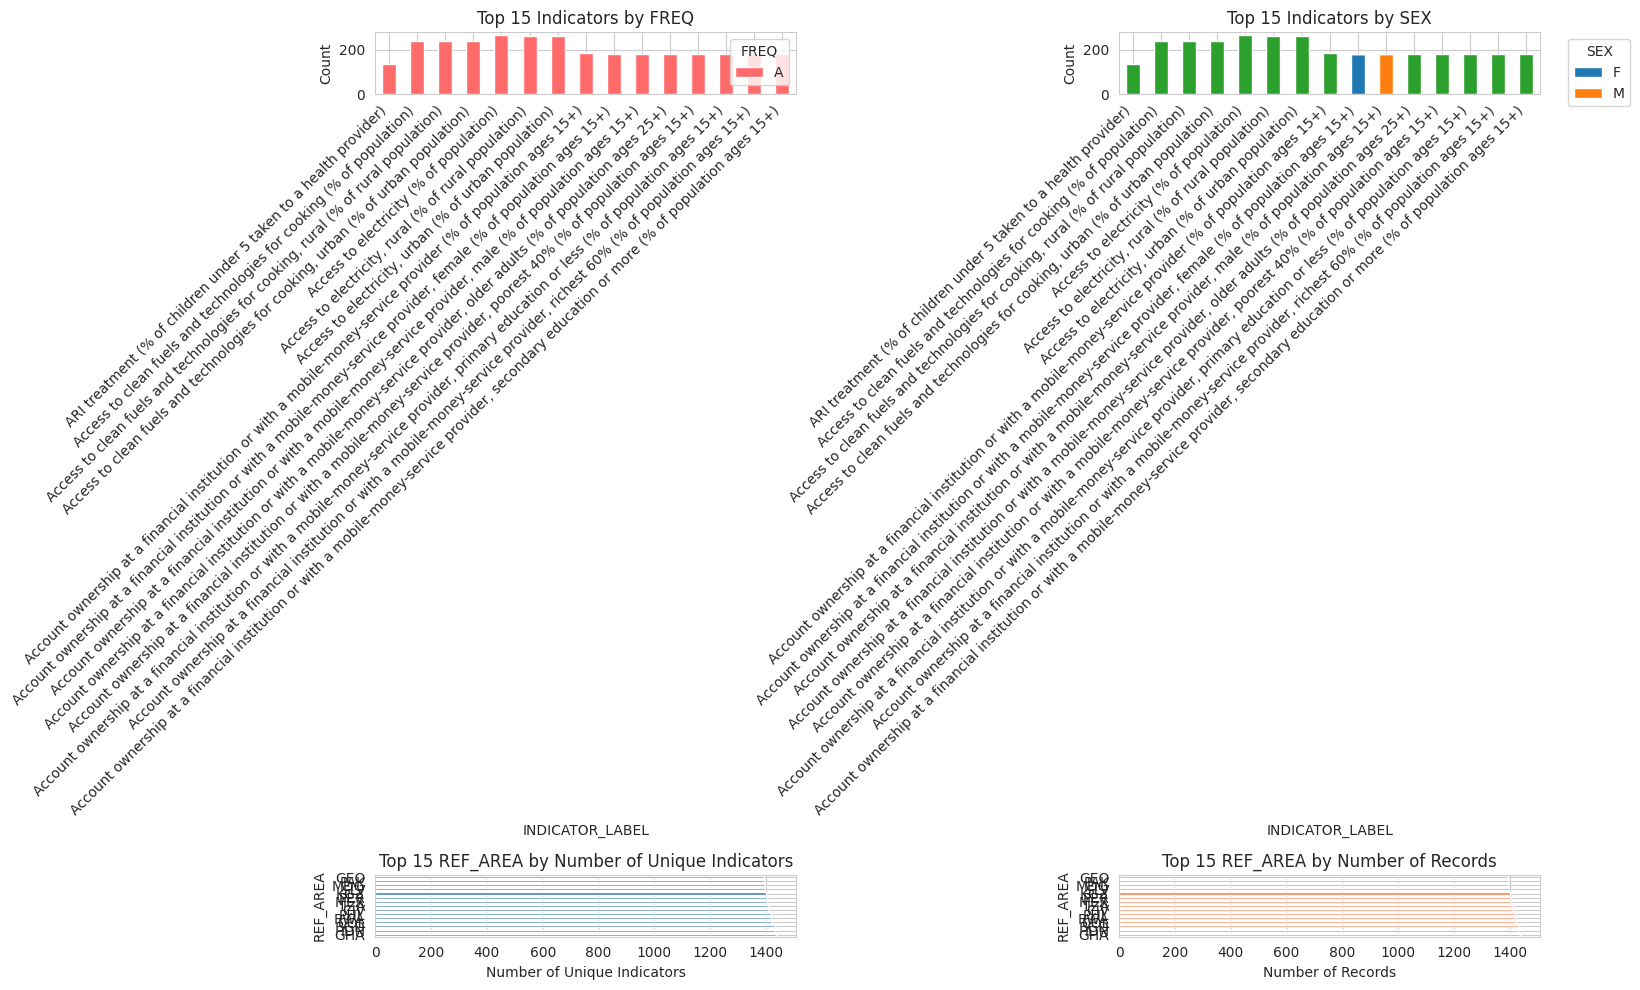

In [21]:
# Cross-tabulation with other columns
print("=" * 80)
print("CROSS-TABULATION ANALYSIS")
print("=" * 80)

# Check available columns
print("\nAvailable columns in the dataset:")
print(df.columns.tolist())

# Cross-tabulation with REF_AREA
ct_ref_area = pd.crosstab(df['INDICATOR_LABEL'], df['REF_AREA'], margins=True)
print("\n\nCross-tabulation: INDICATOR vs REF_AREA (Top 10 indicators)")
print(ct_ref_area.head(10))

# Cross-tabulation with SEX
ct_sex = pd.crosstab(df['INDICATOR_LABEL'], df['SEX'])
print("\n\nCross-tabulation: INDICATOR vs SEX")
print(ct_sex.head(10))

# Cross-tabulation with FREQ
ct_freq = pd.crosstab(df['INDICATOR_LABEL'], df['FREQ'])
print("\n\nCross-tabulation: INDICATOR vs FREQ")
print(ct_freq)

# Visualization of cross-tabulation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# INDICATOR vs FREQ
ct_freq_top = ct_freq.head(15)
ct_freq_top.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Top 15 Indicators by FREQ')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='FREQ')
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# INDICATOR vs SEX
ct_sex_top = ct_sex.head(15)
ct_sex_top.plot(kind='bar', ax=axes[0, 1], stacked=True)
axes[0, 1].set_title('Top 15 Indicators by SEX')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='SEX', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Count of indicators per REF_AREA
ref_area_counts = df.groupby('REF_AREA')['INDICATOR'].nunique().sort_values(ascending=False).head(15)
ref_area_counts.plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Top 15 REF_AREA by Number of Unique Indicators')
axes[1, 0].set_xlabel('Number of Unique Indicators')

# Count of records per REF_AREA
ref_area_records = df['REF_AREA'].value_counts().head(15)
ref_area_records.plot(kind='barh', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Top 15 REF_AREA by Number of Records')
axes[1, 1].set_xlabel('Number of Records')

plt.tight_layout()
plt.show()

## Summary & Key Insights

In [22]:
# Generate comprehensive summary
print("=" * 80)
print("EDA SUMMARY FOR INDICATORS COLUMN")
print("=" * 80)

summary_info = {
    'Total Records': len(df),
    'Unique Indicators': df['INDICATOR_LABEL'].nunique(),
    'Missing Values': df['INDICATOR_LABEL'].isna().sum(),
    'Missing Percentage': f"{(df['INDICATOR_LABEL'].isna().sum() / len(df)) * 100:.2f}%",
    'Most Frequent Indicator': indicator_counts.index[0],
    'Most Frequent Count': indicator_counts.iloc[0],
    'Least Frequent Indicator': indicator_counts.index[-1],
    'Least Frequent Count': indicator_counts.iloc[-1],
    'Average Frequency': f"{indicator_counts.mean():.2f}",
    'Median Frequency': f"{indicator_counts.median():.2f}",
    'Max Frequency': indicator_counts.max(),
    'Min Frequency': indicator_counts.min(),
    'Standard Deviation': f"{indicator_counts.std():.2f}",
    'Unique REF_AREA': df['REF_AREA'].nunique(),
    'Unique SEX Values': df['SEX'].nunique(),
    'Unique FREQ Values': df['FREQ'].nunique(),
}

for key, value in summary_info.items():
    print(f"{key:<30}: {value}")

print("\n" + "=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)
print(f"✓ No critical missing values detected in INDICATOR column" if missing_count == 0 else f"⚠ {missing_count} missing values detected")
print(f"✓ Data is well-distributed across {unique_count} unique indicators")
print(f"✓ Top indicator '{indicator_counts.index[0]}' represents {(indicator_counts.iloc[0]/len(df))*100:.2f}% of data")

EDA SUMMARY FOR INDICATORS COLUMN
Total Records                 : 289303
Unique Indicators             : 1486
Missing Values                : 0
Missing Percentage            : 0.00%
Most Frequent Indicator       : Survival to age 65, female (% of cohort)
Most Frequent Count           : 265
Least Frequent Indicator      : Other people in need of international protection by country or territory of origin
Least Frequent Count          : 8
Average Frequency             : 194.69
Median Frequency              : 210.00
Max Frequency                 : 265
Min Frequency                 : 8
Standard Deviation            : 59.33
Unique REF_AREA               : 265
Unique SEX Values             : 3
Unique FREQ Values            : 1

DATA QUALITY ASSESSMENT
✓ No critical missing values detected in INDICATOR column
✓ Data is well-distributed across 1486 unique indicators
✓ Top indicator 'Survival to age 65, female (% of cohort)' represents 0.09% of data


# Exploratory Data Analysis (EDA) for INDICATORS Column

This notebook performs a comprehensive exploratory data analysis on the INDICATORS column from the WB_WDI_WIDEF dataset.